# MNIST Handwritten Digit Classification with TensorFlow Keras

---



## Objective:
This notebook aims to demonstrate and compare two fundamental deep learning models for image classification: an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN), using the popular MNIST handwritten digit dataset. We will build, train, and evaluate both models using only TensorFlow Keras APIs.

### What is the MNIST Dataset?

The MNIST (Modified National Institute of Standards and Technology) dataset is a large database of handwritten digits that is commonly used for training various image processing systems. It consists of 60,000 training images and 10,000 testing images of handwritten digits (0-9). Each image is a grayscale image of size 28x28 pixels.

### Image Classification Problem Statement

Image classification is a core task in computer vision, where the goal is to categorize and label groups of pixels or vector data within an image based on its visual content. In the context of MNIST, the problem is to correctly identify the digit represented in each handwritten image.

### How Neural Networks Solve Digit Recognition

Neural networks, inspired by the human brain, are powerful tools for pattern recognition. For digit recognition, a neural network learns to identify features (like edges, loops, and lines) within the image pixels. During training, it adjusts its internal parameters (weights and biases) to minimize the difference between its predicted digit and the actual digit. Over time, the network learns to map input images to their correct digit labels.

### Difference Between ANN and CNN

*   **Artificial Neural Networks (ANNs)**: These are fundamental neural networks composed of layers of neurons (perceptrons) where each neuron in one layer is connected to every neuron in the next layer. They are good for tabular data but struggle with high-dimensional data like images because they treat each pixel as an independent feature, losing spatial information.

*   **Convolutional Neural Networks (CNNs)**: CNNs are a specialized type of neural network designed for processing data with a grid-like topology, such as images. They incorporate specialized layers like convolutional layers and pooling layers, which allow them to automatically and adaptively learn spatial hierarchies of features from images. This makes them highly effective for computer vision tasks.

### Why CNN is Preferred for Image Data

CNNs are preferred for image data due to several key advantages:

1.  **Spatial Hierarchy Learning**: Convolutional layers can detect local features (e.g., edges, corners) in the early layers and then combine these into more complex patterns (e.g., shapes, objects) in deeper layers.
2.  **Parameter Sharing**: Unlike ANNs where each connection has a unique weight, CNNs use shared weights in their convolutional filters. This significantly reduces the number of parameters, making the model more efficient and less prone to overfitting.
3.  **Translation Invariance**: Pooling layers in CNNs make the network robust to small shifts or distortions in the input image. This means a CNN can still recognize an object even if its position in the image changes slightly.

## 2. Import Libraries

In [2]:
# Import necessary libraries
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Display TensorFlow and Keras versions
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.21.0
Keras Version: 3.15.1


## 3. Load MNIST Dataset Using Keras

In [11]:
# Load the MNIST dataset
import tensorflow as tf
from tensorflow import keras
import numpy as np
import ssl
import urllib
import ssl
import matplotlib.pyplot as plt
import seaborn as sns

ssl._create_default_https_context = ssl._create_unverified_context

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display dataset characteristics
print(f"Training images shape: {x_train.shape}")
print(f"Testing images shape: {x_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Override default SSL context globally for urllib requests


# Number of classes
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

# Image resolution
image_resolution = f"{x_train.shape[1]} x {x_train.shape[2]} grayscale images"
print(f"Image resolution: {image_resolution}")

Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)
Number of classes: 10
Image resolution: 28 x 28 grayscale images


## 4. Explore Dataset

### 4.1. Display First 10 Images

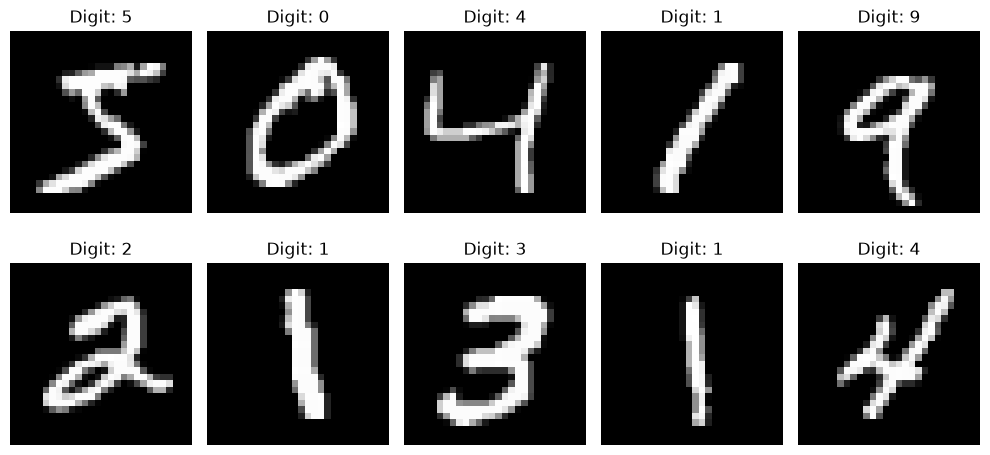

In [12]:
# Display the first 10 training images with their labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1) # Create a 2x5 grid of subplots
    plt.imshow(x_train[i], cmap='gray') # Display the image in grayscale
    plt.title(f"Digit: {y_train[i]}") # Set the title to the corresponding digit label
    plt.axis('off') # Hide the axes
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show() # Display the plot

### 4.2. Display Pixel Values of a Single Image

In [13]:
import pandas as pd

# Show the shape of a single image
print(f"Shape of a single image (x_train[0]): {x_train[0].shape}")

# Display pixel matrix using a DataFrame for the first image
print("\nPixel matrix for the first image (x_train[0]):")
# Convert the 2D array of the first image into a Pandas DataFrame for better visualization
pd.DataFrame(x_train[0])

Shape of a single image (x_train[0]): (28, 28)

Pixel matrix for the first image (x_train[0]):


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


### 4.3. Plot Digit Distribution

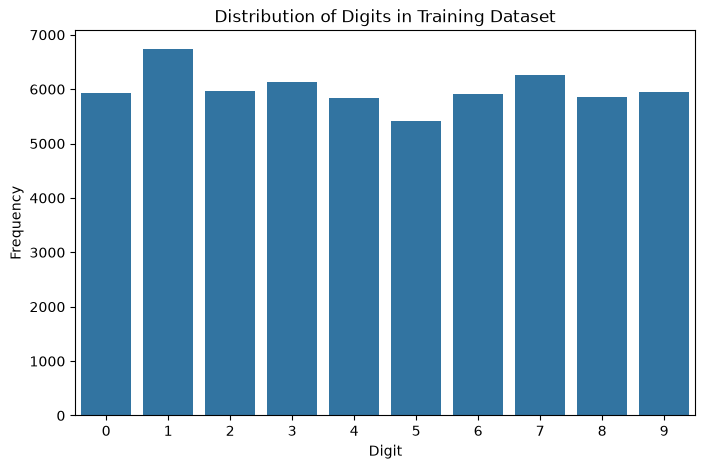

In [14]:
# Plot the distribution of digits in the training set
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train) # Create a count plot for the training labels
plt.title('Distribution of Digits in Training Dataset') # Set the plot title
plt.xlabel('Digit') # Label the x-axis
plt.ylabel('Frequency') # Label the y-axis
plt.show() # Display the plot

## 5. Data Preprocessing

### 5.1. Normalization

Pixel values in images typically range from 0 to 255. Normalizing these values to a range of 0 to 1 helps in faster and more stable training of neural networks. This is achieved by dividing every pixel value by 255.0.

In [15]:
# Normalize pixel values from [0, 255] to [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"Normalized x_train min: {x_train_normalized.min()}, max: {x_train_normalized.max()}")
print(f"Normalized x_test min: {x_test_normalized.min()}, max: {x_test_normalized.max()}")

Normalized x_train min: 0.0, max: 1.0
Normalized x_test min: 0.0, max: 1.0


### 5.2. Prepare Data for Artificial Neural Network (ANN)

For an Artificial Neural Network (ANN), the input layer expects a 1D array of features. Since our images are 28x28, we need to flatten each image into a single vector of 28 * 28 = 784 pixels.

In [16]:
# Flatten images for ANN: 28x28 -> 784
x_train_ann = x_train_normalized.reshape(-1, 28 * 28)
x_test_ann = x_test_normalized.reshape(-1, 28 * 28)

print(f"Shape of x_train_ann after flattening: {x_train_ann.shape}")
print(f"Shape of x_test_ann after flattening: {x_test_ann.shape}")

Shape of x_train_ann after flattening: (60000, 784)
Shape of x_test_ann after flattening: (10000, 784)


### 5.3. Prepare Data for Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) expect input images to have a channel dimension. For grayscale images like MNIST, we add a single channel, transforming the shape from `(samples, height, width)` to `(samples, height, width, channels)`. Here, it becomes `(samples, 28, 28, 1)`.

In [17]:
# Reshape images for CNN: (samples, 28, 28) -> (samples, 28, 28, 1)
x_train_cnn = x_train_normalized.reshape(x_train_normalized.shape[0], 28, 28, 1)
x_test_cnn = x_test_normalized.reshape(x_test_normalized.shape[0], 28, 28, 1)

print(f"Shape of x_train_cnn after reshaping: {x_train_cnn.shape}")
print(f"Shape of x_test_cnn after reshaping: {x_test_cnn.shape}")

Shape of x_train_cnn after reshaping: (60000, 28, 28, 1)
Shape of x_test_cnn after reshaping: (10000, 28, 28, 1)


### 5.4. Convert Labels to Categorical

For multi-class classification problems, especially when using a `softmax` activation in the output layer and `categorical_crossentropy` as the loss function, it's necessary to convert integer labels into a one-hot encoded format. For example, the digit '5' would be converted from `5` to `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`.

In [18]:
# Convert labels to one-hot encoding
y_train_categorical = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=num_classes)

print(f"Original y_train sample: {y_train[0]}")
print(f"Categorical y_train sample: {y_train_categorical[0]}")
print(f"Shape of y_train_categorical: {y_train_categorical.shape}")
print(f"Shape of y_test_categorical: {y_test_categorical.shape}")

Original y_train sample: 5
Categorical y_train sample: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Shape of y_train_categorical: (60000, 10)
Shape of y_test_categorical: (10000, 10)


---

# PART 1: Artificial Neural Network (ANN) Model

## 6. Build ANN Using Keras Sequential API

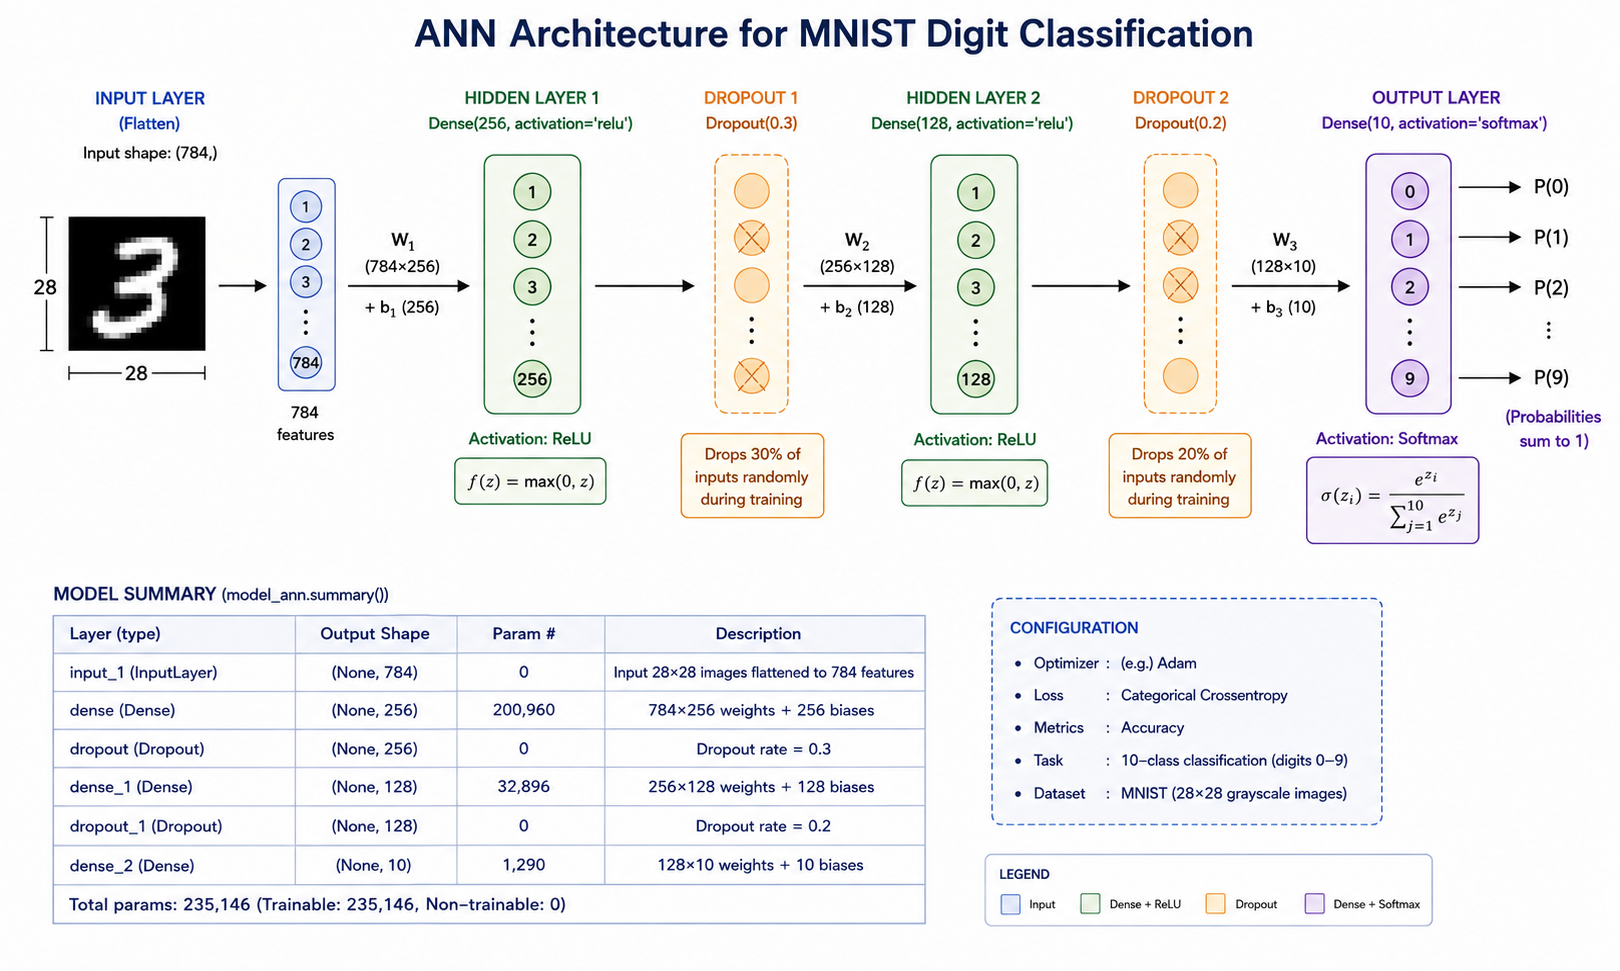

In [20]:
# Define the ANN model architecture using Keras Sequential API
from tensorflow.keras import layers
model_ann = keras.Sequential([
    # Input Layer: Flattens the 28x28 image into a 784-element vector
    # input_shape specifies the shape of the input data (784 features for each image)
    keras.Input(shape=(784,)),

    # Hidden Layer 1: Dense layer with 256 neurons and ReLU activation function
    # ReLU (Rectified Linear Unit) is a common activation function that helps with non-linearity
    layers.Dense(256, activation="relu"),

    # Dropout Layer: Randomly sets 30% of input units to 0 at each update during training
    # This helps prevent overfitting by making the network less reliant on specific neurons
    layers.Dropout(0.3),

    # Hidden Layer 2: Dense layer with 128 neurons and ReLU activation function
    layers.Dense(128, activation="relu"),

    # Dropout Layer: Randomly sets 20% of input units to 0
    layers.Dropout(0.2),

    # Output Layer: Dense layer with 10 neurons (one for each digit 0-9)
    # Softmax activation converts raw outputs (logits) into probabilities that sum to 1
    layers.Dense(num_classes, activation="softmax") # num_classes is 10 for MNIST
])

# Display the model summary, which includes the layers, output shape, and number of parameters
model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile ANN Model

In [21]:
# Compile the ANN model
# Optimizer: 'adam' is an efficient optimization algorithm suitable for a wide range of problems
# Loss Function: 'categorical_crossentropy' is used for multi-class classification with one-hot encoded labels
# Metrics: 'accuracy' monitors the proportion of correctly classified samples during training and evaluation
model_ann.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

## 8. Train ANN Model

In [22]:
# Train the ANN model
# x_train_ann: Flattened and normalized training images
# y_train_categorical: One-hot encoded training labels
# epochs: Number of times the model will iterate over the entire training dataset
# batch_size: Number of samples per gradient update
# validation_split: Fraction of the training data to be used as validation data
print("\nTraining ANN Model...")
ann_history = model_ann.fit(x_train_ann, y_train_categorical,
                            epochs=10,
                            batch_size=32,
                            validation_split=0.2) # Use 20% of training data for validation


Training ANN Model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9067 - loss: 0.3098 - val_accuracy: 0.9627 - val_loss: 0.1283
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9547 - loss: 0.1488 - val_accuracy: 0.9692 - val_loss: 0.1031
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9651 - loss: 0.1151 - val_accuracy: 0.9714 - val_loss: 0.0931
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9695 - loss: 0.0983 - val_accuracy: 0.9757 - val_loss: 0.0825
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9733 - loss: 0.0838 - val_accuracy: 0.9744 - val_loss: 0.0826
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9765 - loss: 0.0762 - val_accuracy: 0.9757 - val_loss: 0.0832
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9782 - loss: 0.0686 - val_accuracy: 0.9776 - val_loss: 0.0861
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0

## 9. Visualize ANN Training

After training a neural network, it's crucial to visualize its performance over epochs to diagnose potential issues like overfitting or underfitting and to understand how well the model has converged.

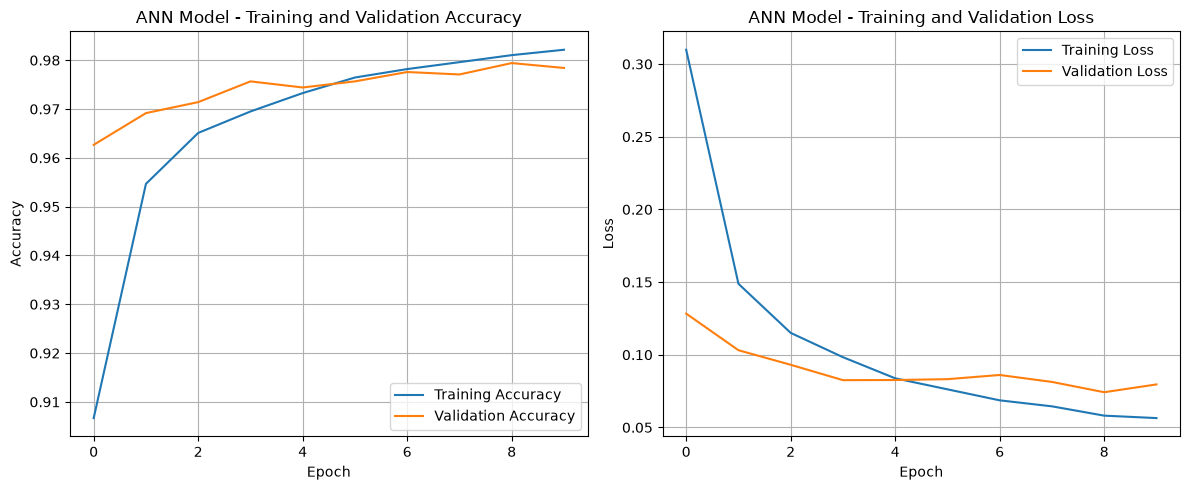

In [23]:
# Plotting Accuracy Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # Create a subplot for accuracy
plt.plot(ann_history.history['accuracy'], label='Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Loss Curve
plt.subplot(1, 2, 2) # Create a subplot for loss
plt.plot(ann_history.history['loss'], label='Training Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Explanation of Training Curves:

*   **Overfitting**: Occurs when the model learns the training data too well, including its noise, leading to high accuracy on the training set but poor performance on unseen (validation) data. Visually, the training loss decreases while validation loss starts increasing, and validation accuracy plateaus or drops.

*   **Underfitting**: Occurs when the model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and validation sets. Both training and validation loss remain high, and accuracy stays low.

*   **Convergence**: Refers to the point where the model's performance (loss) stops significantly improving on the validation set. An ideal scenario is when both training and validation loss decrease together and then stabilize at a low point, indicating that the model has learned the patterns effectively without overfitting.

## 10. ANN Evaluation

After training and visualizing, it's essential to evaluate the model's performance on a completely unseen test dataset to get an unbiased estimate of its generalization capability.

In [24]:
# Evaluate the ANN model on the test dataset
print("\nEvaluating ANN Model on Test Data...")
ann_test_loss, ann_test_accuracy = model_ann.evaluate(x_test_ann, y_test_categorical, verbose=0)

print(f"ANN Test Loss: {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_accuracy:.4f}")

# Generate predictions for the test set
ann_predictions = model_ann.predict(x_test_ann)
ann_predicted_classes = np.argmax(ann_predictions, axis=1)

# Generate Confusion Matrix
ann_cm = confusion_matrix(y_test, ann_predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues')
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print Classification Report
print("\nANN Classification Report:")
print(classification_report(y_test, ann_predicted_classes))


Evaluating ANN Model on Test Data...
ANN Test Loss: 0.0691
ANN Test Accuracy: 0.9810
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step


NameError: name 'confusion_matrix' is not defined

---

# PART 2: Convolutional Neural Network (CNN) Model

## 11. Build CNN Using Keras

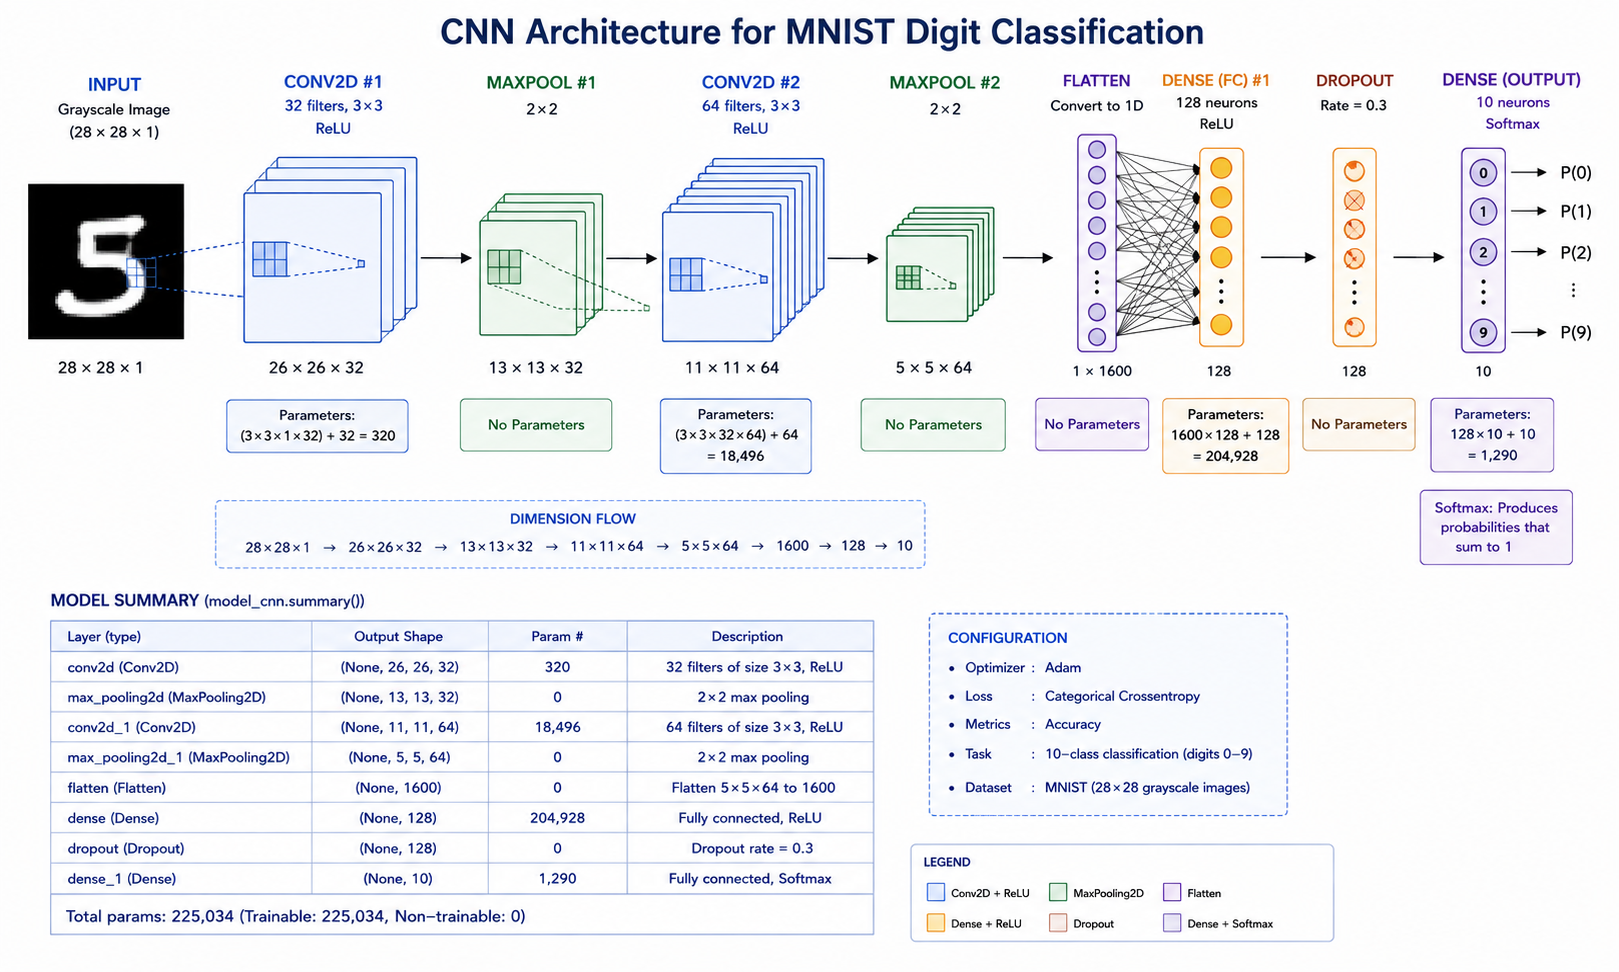

In [30]:
# Define the CNN model architecture using Keras Sequential API
model_cnn = keras.Sequential([
    # Convolutional Layer 1: Learn local patterns
    # 32 filters, each 3x3 kernel size, ReLU activation
    # input_shape=(28, 28, 1) specifies height, width, and single channel for grayscale images
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),

    # MaxPooling Layer 1: Downsample the feature maps, reducing spatial dimensions
    # Default pool_size=(2, 2) reduces height and width by half
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 2: Learn more complex patterns
    # 64 filters, each 3x3 kernel size, ReLU activation
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),

    # MaxPooling Layer 2: Further downsample the feature maps
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten Layer: Convert the 2D feature maps into a 1D vector
    # This is necessary before passing to Dense (fully connected) layers
    layers.Flatten(),

    # Dense Layer 1: Fully connected layer with 128 neurons and ReLU activation
    layers.Dense(128, activation="relu"),

    # Dropout Layer: Helps prevent overfitting by randomly setting 30% of input units to 0
    layers.Dropout(0.3),

    # Output Layer: Dense layer with 10 neurons (one for each digit 0-9)
    # Softmax activation for multi-class probability distribution
    layers.Dense(num_classes, activation="softmax")
])

# Display the model summary
model_cnn.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Compile CNN Model

In [31]:
# Compile the CNN model
# Using 'adam' optimizer for efficient training
# 'categorical_crossentropy' as loss function for one-hot encoded labels
# Monitoring 'accuracy' during training
model_cnn.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

## 13. Train CNN Model

In [32]:
# Train the CNN model
# x_train_cnn: Reshaped and normalized training images for CNN
# y_train_categorical: One-hot encoded training labels
# epochs: Number of training iterations
# validation_split: 20% of training data used for validation
print("\nTraining CNN Model...")
cnn_history = model_cnn.fit(x_train_cnn, y_train_categorical,
                            epochs=10,
                            batch_size=32,
                            validation_split=0.2) # Use 20% of training data for validation


Training CNN Model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9381 - loss: 0.1988 - val_accuracy: 0.9827 - val_loss: 0.0586
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9806 - loss: 0.0652 - val_accuracy: 0.9867 - val_loss: 0.0417
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9861 - loss: 0.0471 - val_accuracy: 0.9888 - val_loss: 0.0386
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9895 - val_loss: 0.0372
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.9902 - val_loss: 0.0329
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9925 - loss: 0.0231 - val_accuracy: 0.9904 - val_loss: 0.0343
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9932 - loss: 0.0200 - val_accuracy: 0.9915 - val_loss: 0.0340
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accur

## 14. CNN Training Visualization

Similar to the ANN, visualizing the training and validation curves for the CNN helps us understand its learning progress, detect potential overfitting or underfitting, and observe its convergence behavior. We expect to see improved performance compared to the ANN due to CNN's ability to capture spatial features effectively.

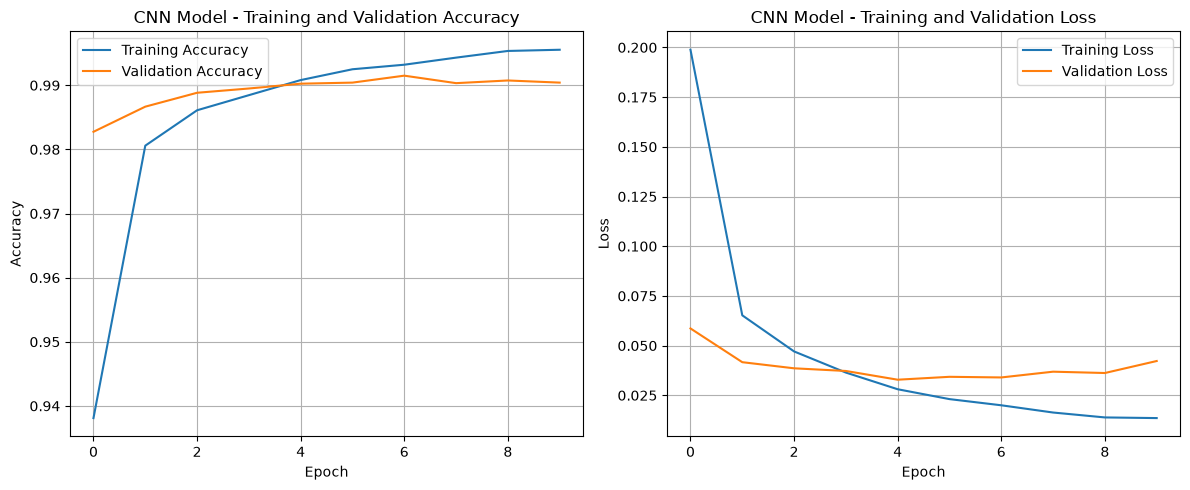

In [33]:
# Plotting Accuracy Curve for CNN
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Loss Curve for CNN
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Explaining Improvement Compared to ANN:

*   **Higher Accuracy**: You should observe that the CNN achieves significantly higher accuracy on both training and validation sets compared to the ANN. This is primarily because CNNs are designed to process image data by using convolutional filters that detect spatial hierarchies of features (e.g., edges, textures, patterns).
*   **Lower Loss**: Correspondingly, the loss values (both training and validation) for the CNN should be considerably lower than those of the ANN, indicating a better fit to the data.
*   **Better Generalization**: The gap between training and validation curves might also be smaller or more stable for the CNN, suggesting better generalization capabilities and less overfitting, thanks to features like parameter sharing and pooling layers.

## 15. CNN Evaluation

Now, let's evaluate the CNN model on the unseen test dataset. This step provides a final, unbiased assessment of how well the CNN generalizes to new handwritten digits.

In [34]:
# Evaluate the CNN model on the test dataset
print("\nEvaluating CNN Model on Test Data...")
cnn_test_loss, cnn_test_accuracy = model_cnn.evaluate(x_test_cnn, y_test_categorical, verbose=0)

print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")

# Generate predictions for the test set
cnn_predictions = model_cnn.predict(x_test_cnn)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Generate Confusion Matrix for CNN
cnn_cm = confusion_matrix(y_test, cnn_predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print Classification Report for CNN
print("\nCNN Classification Report:")
print(classification_report(y_test, cnn_predicted_classes))


Evaluating CNN Model on Test Data...
CNN Test Loss: 0.0333
CNN Test Accuracy: 0.9914
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


NameError: name 'confusion_matrix' is not defined

## 16. Prediction Visualization

To visually understand the CNN's performance, let's create a function to predict a digit from a given image, display the image, and show the actual digit, the predicted digit, and its confidence score.

Visualizing predictions for 10 random test images:


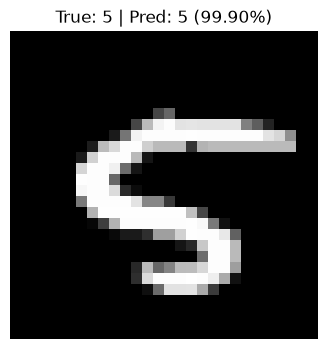

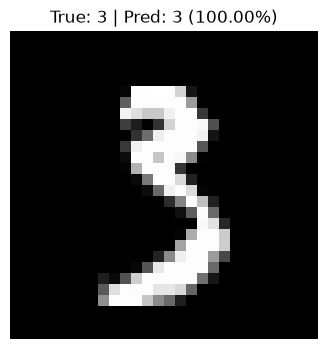

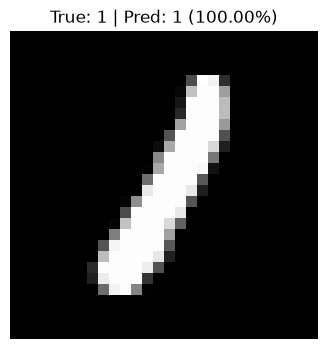

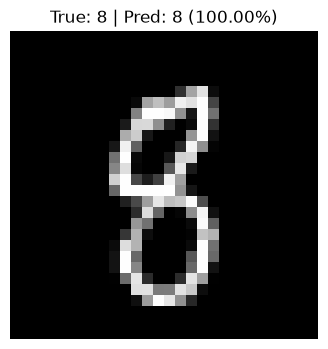

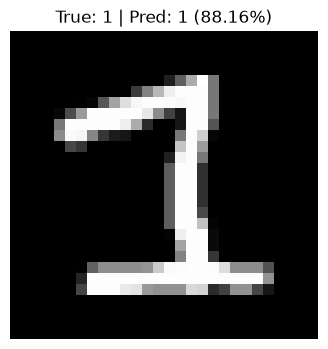

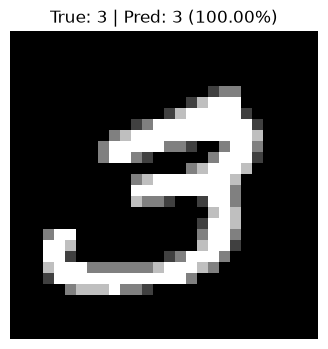

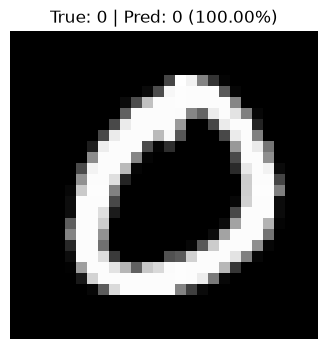

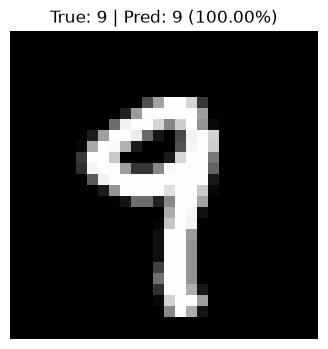

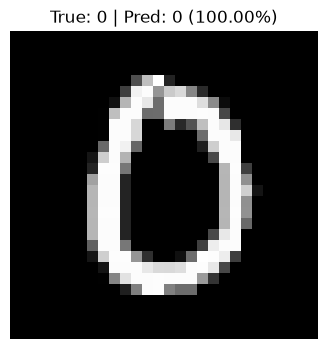

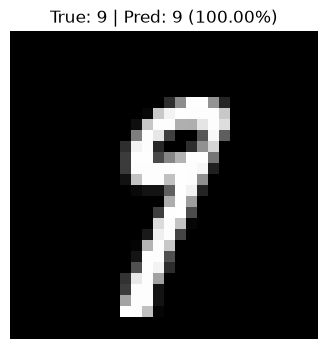

In [35]:
def predict_digit(image_index):
    """
    Takes an index from the test set, predicts the digit using the trained CNN model,
    and visualizes the image along with prediction details.
    """
    # Get the original image and its true label
    original_image = x_test[image_index]
    true_label = y_test[image_index]

    # Get the preprocessed image for CNN prediction
    # Reshape to (1, 28, 28, 1) for a single image prediction
    input_image_for_cnn = x_test_cnn[image_index:image_index+1]

    # Make prediction using the CNN model
    prediction = model_cnn.predict(input_image_for_cnn, verbose=0)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Display the image and prediction details
    plt.figure(figsize=(4, 4))
    plt.imshow(original_image, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Run prediction on 10 random test images
print("Visualizing predictions for 10 random test images:")
random_indices = np.random.choice(len(x_test), 10, replace=False)
for idx in random_indices:
    predict_digit(idx)

---

## 17. ANN vs CNN Comparison

To objectively compare the performance of the Artificial Neural Network (ANN) and the Convolutional Neural Network (CNN), we will summarize their test accuracy and loss in a DataFrame and visualize this comparison with a bar chart.

Model Comparison:
  Model  Test Accuracy  Test Loss
0   ANN         0.9810   0.069095
1   CNN         0.9914   0.033294


/var/folders/35/0fqhg0y52n1272p46_1b_kb40000gn/T/ipykernel_7928/807239702.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=comparison_df, palette='viridis')
/var/folders/35/0fqhg0y52n1272p46_1b_kb40000gn/T/ipykernel_7928/807239702.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Loss', data=comparison_df, palette='magma')


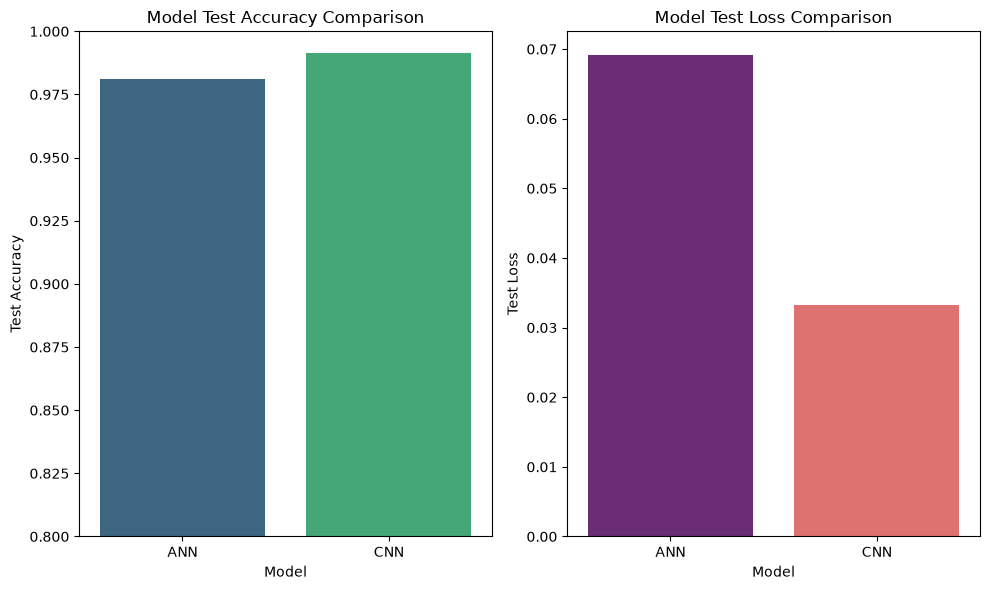

In [37]:
# Create a DataFrame for model comparison
comparison_data = {
    'Model': ['ANN', 'CNN'],
    'Test Accuracy': [ann_test_accuracy, cnn_test_accuracy],
    'Test Loss': [ann_test_loss, cnn_test_loss]
}
comparison_df = pd.DataFrame(comparison_data)

print("Model Comparison:")
print(comparison_df)

# Plot comparison chart
plt.figure(figsize=(10, 6))

# Subplot for Test Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Test Accuracy', data=comparison_df, palette='viridis')
plt.title('Model Test Accuracy Comparison')
plt.ylim(0.8, 1.0) # Set y-axis limit for better visualization of differences

# Subplot for Test Loss
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Test Loss', data=comparison_df, palette='magma')
plt.title('Model Test Loss Comparison')

plt.tight_layout()
plt.show()

## 18. Final Explanation

After building, training, and evaluating both an ANN and a CNN for MNIST handwritten digit classification, we can draw some conclusions regarding their performance and the underlying reasons.

### Why CNN Gives Better Accuracy

The comparison clearly shows that the CNN model significantly outperforms the ANN model in terms of test accuracy and achieves a lower test loss. This superior performance of CNNs in image classification tasks can be attributed to several architectural advantages:

1.  **Local Receptive Fields and Parameter Sharing**: Convolutional layers use small filters (kernels) that scan local regions of the input image. These filters detect specific features (e.g., edges, corners, textures) wherever they appear in the image. Critically, the same filter (with the same weights) is applied across the entire image, a concept known as **parameter sharing**. This drastically reduces the number of parameters compared to an ANN, making the model more efficient and less prone to overfitting.

2.  **Feature Extraction and Hierarchy**: CNNs are inherently designed for **feature extraction**. Early layers learn basic features, and subsequent layers learn to combine these basic features into more complex and abstract representations. For example, an early layer might detect edges, a middle layer might detect shapes like circles and squares, and a deeper layer might detect combinations of shapes forming digits. This hierarchical feature learning is highly effective for understanding image content.

3.  **Translational Invariance**: Through the use of pooling layers (like MaxPooling), CNNs become robust to slight shifts or distortions in the input image. If a digit is slightly moved or rotated, the pooling layer ensures that the essential features are still captured, leading to **translational invariance**. ANNs, on the other hand, treat each pixel location independently, making them sensitive to shifts.

### Importance of Convolution Filters

Convolution filters (or kernels) are the core of CNNs. They are small matrices of numbers that are convolved (slid) across the input image. Each filter is designed to activate when it detects a specific type of feature. For instance, one filter might be optimized to detect horizontal edges, another for vertical edges, and so on. During the training process, the neural network learns the optimal values for these filter weights to best extract relevant features for the classification task.

### Real-world Applications

The principles demonstrated with the simple MNIST dataset scale up to complex real-world computer vision tasks. CNNs are the backbone of modern applications such as:

*   **Self-driving cars**: Object detection (pedestrians, other vehicles, traffic signs).
*   **Medical imaging**: Detecting anomalies like tumors in X-rays or MRI scans.
*   **Facial recognition**: Unlocking phones, security systems.
*   **Image and video analysis**: Content moderation, search engines.
*   **Robotics**: Object manipulation and navigation.

In conclusion, while ANNs can perform digit recognition, their lack of spatial awareness makes them less effective for image data. CNNs, with their specialized architecture for hierarchical feature learning and translational invariance, are the state-of-the-art for most computer vision problems, providing significantly higher accuracy and more robust performance.

## 19. Model Serialization and Inference

After training, it's good practice to save your models to disk. This allows you to reload them later without retraining, deploy them, or share them. Keras models can be saved in the TensorFlow SavedModel format, which preserves the model's architecture, weights, and training configuration (optimizer, loss, and metrics).

In [25]:
# Save the ANN model
model_ann.save('mnist_ann_model.keras')
print("ANN Model saved as 'mnist_ann_model.keras'")

# Save the CNN model
model_cnn.save('mnist_cnn_model.keras')
print("CNN Model saved as 'mnist_cnn_model.keras'")

ANN Model saved as 'mnist_ann_model.keras'
CNN Model saved as 'mnist_cnn_model.keras'


To use a saved model, you first need to load it back into memory. Keras provides a simple function for this (`keras.models.load_model`). Once loaded, the model is ready to be used for making predictions.

In [26]:
# Load the saved ANN model
loaded_ann_model = keras.models.load_model('mnist_ann_model.keras')
print("ANN Model loaded successfully.")

# Load the saved CNN model
loaded_cnn_model = keras.models.load_model('mnist_cnn_model.keras')
print("CNN Model loaded successfully.")

ANN Model loaded successfully.
CNN Model loaded successfully.


### Inference Pipeline

An inference pipeline involves preparing new, unseen data for prediction, passing it through the loaded model, and interpreting the output. For our MNIST models, this includes:

1.  **Loading an image**: This could be a new image or one from our test set.
2.  **Preprocessing**: Normalizing pixel values and reshaping the image to match the input requirements of the ANN (flattened) and CNN (28x28x1).
3.  **Prediction**: Using the `predict` method of the loaded model.
4.  **Interpreting results**: Converting the model's output (probability distribution) into a predicted digit and a confidence score.

In [27]:
def run_inference(image, ann_model, cnn_model, num_classes):
    """
    Runs inference on a single image using both ANN and CNN models.
    Displays the image and prediction results.
    """

    # Normalize the image
    image_normalized = image.astype('float32') / 255.0

    # Preprocess for ANN
    image_ann = image_normalized.reshape(1, 28 * 28) # Reshape for single image prediction

    # Preprocess for CNN
    image_cnn = image_normalized.reshape(1, 28, 28, 1) # Reshape for single image prediction

    # ANN Prediction
    ann_prediction_raw = ann_model.predict(image_ann, verbose=0)
    ann_predicted_class = np.argmax(ann_prediction_raw)
    ann_confidence = np.max(ann_prediction_raw) * 100

    # CNN Prediction
    cnn_prediction_raw = cnn_model.predict(image_cnn, verbose=0)
    cnn_predicted_class = np.argmax(cnn_prediction_raw)
    cnn_confidence = np.max(cnn_prediction_raw) * 100

    # Display the image and prediction details
    plt.figure(figsize=(6, 3))
    plt.imshow(image, cmap='gray')
    plt.title(f"True Label: (Not Available) ")
    plt.axis('off')
    plt.show()

    print(f"  ANN Prediction: {ann_predicted_class} (Confidence: {ann_confidence:.2f}%)")
    print(f"  CNN Prediction: {cnn_predicted_class} (Confidence: {cnn_confidence:.2f}%)")

    return ann_predicted_class, cnn_predicted_class

### Demonstrate Inference

Let's pick a random image from our test set and run it through our loaded ANN and CNN models to see their predictions.

Demonstrating inference on a random test image:
Original True Label: 3


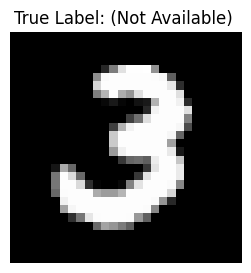

  ANN Prediction: 3 (Confidence: 100.00%)
  CNN Prediction: 3 (Confidence: 100.00%)


In [28]:
print("Demonstrating inference on a random test image:")
random_index = np.random.randint(0, len(x_test))
sample_image = x_test[random_index]
true_label_sample = y_test[random_index]

print(f"Original True Label: {true_label_sample}")
ann_pred, cnn_pred = run_inference(sample_image, loaded_ann_model, loaded_cnn_model, num_classes)

---